In [46]:
# relative path
from hydra import compose, initialize
from omegaconf import OmegaConf

with initialize(config_path="../configs"):
    cfg = compose(config_name="config")

print(OmegaConf.to_yaml(cfg))

paths:
  nako_dir: /nfs/data/nii/data0/GNC/GNC_759
  nnUNet_dir: /nfs/data/nii/data0/GNC/Analysis/GNC_759/ANALYSIS_whole_body_benchmark/nnUNet/



/tmp/ipykernel_643774/941803802.py:5: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="../configs"):


['3D_GRE_TRA_W_COMPOSED_-13_s049_opp.nii', '3D_GRE_TRA_W_COMPOSED_-13_s049_in.nii', '3D_GRE_TRA_W_COMPOSED_-13_s049_W.nii', '3D_GRE_TRA_W_COMPOSED_-13_s049.nii']
(320, 260, 316)


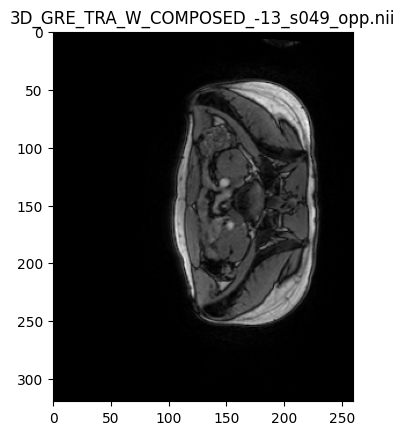

(320, 260, 316)


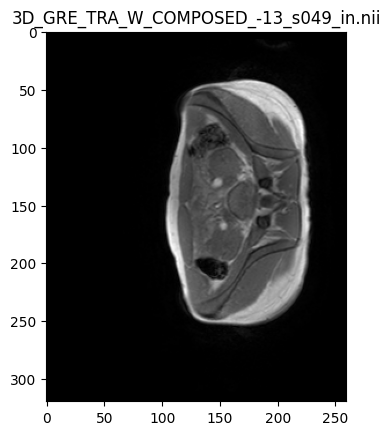

(320, 260, 316)


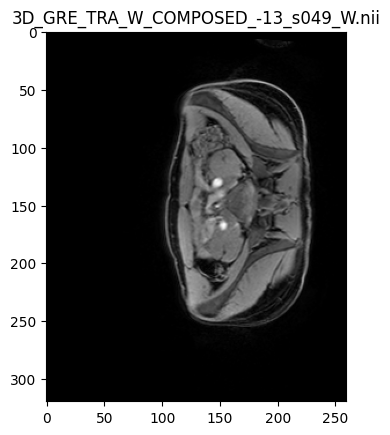

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..490.0].


(320, 260, 316, 4)


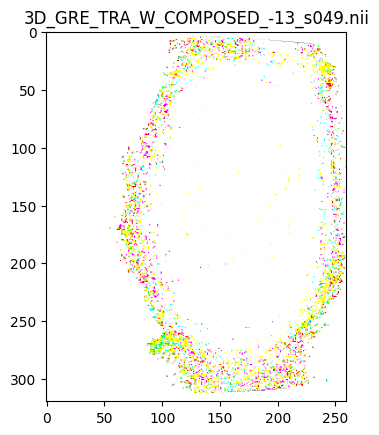

In [47]:

# list all files in path with filter
import glob
import os
import nibabel as nib
import numpy as np
img_path = cfg.paths.nako_dir + "/links/100000/30"
#      "/nfs/data/nii/data0/GNC/GNC_759/links/100002/30/3D_GRE_TRA_4/3D_GRE_TRA_W_COMPOSED_-53_s049.nii"
img_filter = "3D_GRE_TRA_4/3D_GRE_TRA_W_COMPOSE*_s*.nii"
files = glob.glob(os.path.join(img_path, img_filter))
print([os.path.basename(f) for f in files])



import matplotlib.pyplot as plt
for f in files:
    img = nib.load(f)
    img_data = img.get_fdata()
    print(img_data.shape)
    plt.imshow(img_data[:,:,img_data.shape[2]//2], cmap='gray')
    plt.title(os.path.basename(f))
    plt.show()




In [74]:
gt_mask_base_path =  cfg.paths.nako_dir + "/data"

subdirs = [e.name for e in os.scandir(gt_mask_base_path) if e.is_dir()][:1000]
print(len(subdirs))
# keep subdirs where wholebody/total_vibe_and_ours_seg.nii.gz" exists
valid_subdirs = []
for subdir in subdirs:
    mask_path = os.path.join(gt_mask_base_path, subdir, "30/wholebody/total_vibe_and_ours_seg.nii")
    if os.path.exists(mask_path):
        valid_subdirs.append(subdir)
print("Valid subdirs:", valid_subdirs)



1000
Valid subdirs: ['100527', '100550', '100870', '100993', '100807', '100083', '100117', '100160', '100089', '100067', '100010', '100184', '100900', '100894', '100977', '100457', '100999', '100420', '100269', '100287', '100313', '100364', '100723', '100653', '100624', '100729', '100263', '100214', '100380', '100319']


(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 80
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 81
(320, 260, 316)
Unique values in GT mask: 82
(320, 260, 316)
Unique values in GT mask: 82
(320, 260,

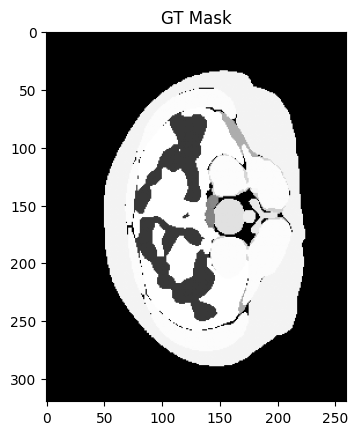

In [79]:
for subject in valid_subdirs:
    gt_mask_path = os.path.join(gt_mask_base_path, subject, "30/wholebody/total_vibe_and_ours_seg.nii")
    gt_mask = nib.load(gt_mask_path)
    gt_mask_data = gt_mask.get_fdata()
    print(gt_mask_data.shape)
    unique_values = np.unique(gt_mask_data)
    print("Unique values in GT mask:", len(unique_values))




plt.imshow(gt_mask_data[:,:,gt_mask_data.shape[2]//2], cmap='gray')
plt.title("GT Mask")
plt.show()

In [ ]:
import nibabel as nib
import xml.etree.ElementTree as ET


xml_content = gt_mask.header.extensions[0].get_content()
root = ET.fromstring(xml_content)

labels = {
    label.text : int(label.get("Key"))
    for label in root.findall(".//Label")
}
print("Labels in GT mask:", labels)

{'spleen': 1,
 'gallbladder': 2,
 'stomach': 3,
 'pancreas': 4,
 'adrenal_gland_right': 5,
 'adrenal_gland_left': 6,
 'lung_upper_lobe_left': 7,
 'lung_lower_lobe_left': 8,
 'lung_upper_lobe_right': 9,
 'lung_middle_lobe_right': 10,
 'lung_lower_lobe_right': 11,
 'esophagus': 12,
 'trachea': 13,
 'thyroid_gland': 14,
 'intestine': 15,
 'duodenum': 16,
 'unused': 17,
 'urinary_bladder': 18,
 'sacrum': 19,
 'heart': 20,
 'pulmonary_vein': 21,
 'brachiocephalic_trunk': 22,
 'subclavian_artery_right': 23,
 'subclavian_artery_left': 24,
 'common_carotid_artery_right': 25,
 'common_carotid_artery_left': 26,
 'brachiocephalic_vein_left': 27,
 'brachiocephalic_vein_right': 28,
 'atrial_appendage_left': 29,
 'superior_vena_cava': 30,
 'inferior_vena_cava': 31,
 'portal_vein_and_splenic_vein': 32,
 'iliac_artery_left': 33,
 'iliac_artery_right': 34,
 'iliac_vena_left': 35,
 'iliac_vena_right': 36,
 'humerus_left': 37,
 'humerus_right': 38,
 'scapula_left': 39,
 'scapula_right': 40,
 'clavicula_l

In [86]:
# find first 10 images 
from pathlib import Path
img_base_path = Path(cfg.paths.nako_dir) / "links"
img_target = "30/3D_GRE_TRA_4/3D_GRE_TRA*"
for subdir in valid_subdirs[:2]:
    target_path = img_base_path / subdir / img_target
    print(f"subject: {subdir}")
    files = glob.glob(str(target_path))
    for f in files:
        print(f"  {os.path.basename(f)}")
        img = nib.load(f)
        img_data = img.get_fdata()
        print(f"  shape: {img_data.shape}")


subject: 100527
  3D_GRE_TRA_F_s047.nii
  shape: (320, 260, 88)
  3D_GRE_TRA_W_s048.nii
  shape: (320, 260, 88)
  3D_GRE_TRA_in_s046.nii
  shape: (320, 260, 88)
  3D_GRE_TRA_W_COMPOSED_-15_s049.nii
  shape: (320, 260, 316, 4)
  3D_GRE_TRA_opp_s045.nii
  shape: (320, 260, 88)
subject: 100550
  3D_GRE_TRA_W_s048.nii
  shape: (320, 260, 88)
  3D_GRE_TRA_in_s046.nii
  shape: (320, 260, 88)
  3D_GRE_TRA_W_COMPOSED_-15_s049.nii
  shape: (320, 260, 316, 4)
  3D_GRE_TRA_opp_s045.nii
  shape: (320, 260, 88)
  3D_GRE_TRA_F_s047.nii
  shape: (320, 260, 88)


In [64]:
# find corresponding gt masks for the first 10 images
mask_base_path = Path(cfg.paths.nako_dir) / "data"
from pathlib import Path
mask_target = "30/wholebody/*nii*"
for subdir in subdirs:
    target_path = mask_base_path / subdir / mask_target
    print(f"Looking for files in: {target_path}")
    files = glob.glob(str(target_path))
    print(f"Subdir: {subdir}, Files found: {len(files)}")
    print(f"Files: {files}")


Looking for files in: /nfs/data/nii/data0/GNC/GNC_759/data/102781/30/wholebody/*nii*
Subdir: 102781, Files found: 5
Files: ['/nfs/data/nii/data0/GNC/GNC_759/data/102781/30/wholebody/total_seg_feb2025_1.nii', '/nfs/data/nii/data0/GNC/GNC_759/data/102781/30/wholebody/subsetFW.nii.gz', '/nfs/data/nii/data0/GNC/GNC_759/data/102781/30/wholebody/wbcomp2.nii.gz', '/nfs/data/nii/data0/GNC/GNC_759/data/102781/30/wholebody/2davg.nii', '/nfs/data/nii/data0/GNC/GNC_759/data/102781/30/wholebody/total_seg_feb2025_tissue_types_1.nii']
Looking for files in: /nfs/data/nii/data0/GNC/GNC_759/data/106427/30/wholebody/*nii*
Subdir: 106427, Files found: 4
Files: ['/nfs/data/nii/data0/GNC/GNC_759/data/106427/30/wholebody/total_seg_feb2025_1.nii', '/nfs/data/nii/data0/GNC/GNC_759/data/106427/30/wholebody/wbcomp2.nii.gz', '/nfs/data/nii/data0/GNC/GNC_759/data/106427/30/wholebody/subsetFW.nii.gz', '/nfs/data/nii/data0/GNC/GNC_759/data/106427/30/wholebody/2davg.nii']
Looking for files in: /nfs/data/nii/data0/GNC